# Scenario 2: Website Analytics Debug
**Lab:** Generative AI for Data Science  
**Name:** Elvis Omondi  
**Date:** 2026-05-25


## My AI Prompt

```
You are a senior Python developer. The following function is producing impossible 
results: bounce rates over 100% and negative avg_session_time values.

Here is the broken code:

def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }
    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })
    return metrics, device_metrics

Identify every bug:
1. bounce_rate: the lambda returns a boolean Series; .mean() on a Series of Series is wrong
2. avg_session_time: result is a Series stored in a dict, not a scalar
3. Negative durations suggest raw timestamps aren't validated

Please:
- Fix all three bugs with inline comments explaining each fix
- Add input validation (check for negative durations, nulls, duration > 86400s)
- Return a clean summary dict of scalar metrics, not Series
- Add a 4-panel dashboard: bounce rate by device, session time histogram,
  pages per session distribution, daily active users trend
- Add a docstring

Assume columns: session_id (str), user_id (str), device_type (str),
timestamp (datetime), page_views (int), duration (float, seconds)
```

**Why I set up the prompt this way:**  
I included the broken code directly so the AI could see exactly what was wrong.
Stating the symptoms (bounce > 100%, negative times) alongside the code let the AI
target all three bugs rather than guess. The main hurdle was the bounce_rate lambda,
the AI initially used `.any()` instead of `.all()`; a follow-up corrected it.


## Generated Code

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Reproducible sample data with intentional dirty values ────────────────────
np.random.seed(7)
n_sessions = 200
base_time = datetime(2026, 4, 1)
records = []

for i in range(n_sessions):
    session_id = f'S{str(i).zfill(4)}'
    user_id    = f'U{np.random.randint(1, 60):03d}'
    device     = np.random.choice(['mobile', 'desktop', 'tablet'], p=[0.55, 0.35, 0.10])
    n_pages    = np.random.choice([1, 2, 3, 4, 5, 8, 12], p=[0.3, 0.2, 0.2, 0.1, 0.1, 0.07, 0.03])
    start      = base_time + timedelta(days=np.random.randint(0, 30),
                                        seconds=np.random.randint(0, 86400))
    duration_s = np.random.exponential(scale=180)
    records.append({'session_id': session_id, 'user_id': user_id,
                    'device_type': device, 'timestamp': start,
                    'page_views': n_pages, 'duration': duration_s})

# Inject dirty rows
records[5]['duration']  = -30
records[10]['duration'] = np.nan
records[15]['duration'] = 90000

logs_df = pd.DataFrame(records)
print(f"Raw data: {logs_df.shape[0]} rows | "
      f"{logs_df['duration'].isna().sum()} nulls | "
      f"{(logs_df['duration'] < 0).sum()} negative durations")


Raw data: 200 rows | 1 nulls | 1 negative durations


In [5]:
def analyze_user_engagement(logs_df: pd.DataFrame) -> tuple:
    """
    Analyse user engagement metrics from web session logs.

    Bug fixes vs original:
    - Bug 1: bounce_rate lambda used x==1 returning a Series per group;
             fixed with (x==1).all() to return a single bool per session.
    - Bug 2: avg_session_time stored a full Series in the dict;
             fixed by chaining .mean() to collapse to a scalar.
    - Bug 3: no validation allowed negative/null durations through;
             fixed with dropna + range filtering before aggregation.
    """
    # ── INPUT VALIDATION ─────────────────────────────────────────────────────
    original_len = len(logs_df)
    logs_df = logs_df.dropna(subset=['duration'])
    logs_df = logs_df[logs_df['duration'] >= 0]
    logs_df = logs_df[logs_df['duration'] <= 86400]
    removed = original_len - len(logs_df)
    if removed > 0:
        print(f"[Validation] Removed {removed} invalid rows ({removed/original_len*100:.1f}%)")
    if logs_df.empty:
        raise ValueError("No valid data remains after validation.")

    # ── METRICS ───────────────────────────────────────────────────────────────
    # FIX 1: use .all() so each group returns one bool, then .mean() = scalar
    bounce_rate = (logs_df.groupby('session_id')['page_views']
                   .apply(lambda x: (x == 1).all()).mean())

    # FIX 2: chain .mean() to get a scalar, not a Series
    avg_session_time = (logs_df.groupby('session_id')['duration'].sum().mean())

    pages_per_session = (logs_df.groupby('session_id')['page_views'].sum().mean())

    logs_df['date'] = pd.to_datetime(logs_df['timestamp']).dt.date
    daily_active_users = logs_df.groupby('date')['user_id'].nunique()

    metrics = {
        'bounce_rate':        round(float(bounce_rate), 4),
        'avg_session_time_s': round(float(avg_session_time), 2),
        'pages_per_session':  round(float(pages_per_session), 2),
        'total_sessions':     logs_df['session_id'].nunique(),
        'total_users':        logs_df['user_id'].nunique(),
    }

    device_metrics = logs_df.groupby('device_type').agg(
        sessions     = ('session_id', 'count'),
        avg_duration = ('duration', 'mean'),
        total_pages  = ('page_views', 'sum')
    ).round(2)

    return metrics, device_metrics, daily_active_users

metrics, device_metrics, daily_active = analyze_user_engagement(logs_df.copy())

print("\n" + "="*50)
print("ENGAGEMENT METRICS SUMMARY")
print("="*50)
for k, v in metrics.items():
    print(f"  {k:<25}: {v}")
print("\nDevice Breakdown:")
print(device_metrics)


[Validation] Removed 3 invalid rows (1.5%)

ENGAGEMENT METRICS SUMMARY
  bounce_rate              : 0.3046
  avg_session_time_s       : 182.69
  pages_per_session        : 3.17
  total_sessions           : 197
  total_users              : 55

Device Breakdown:
             sessions  avg_duration  total_pages
device_type                                     
desktop            65        182.46          208
mobile            110        175.96          349
tablet             22        216.97           67


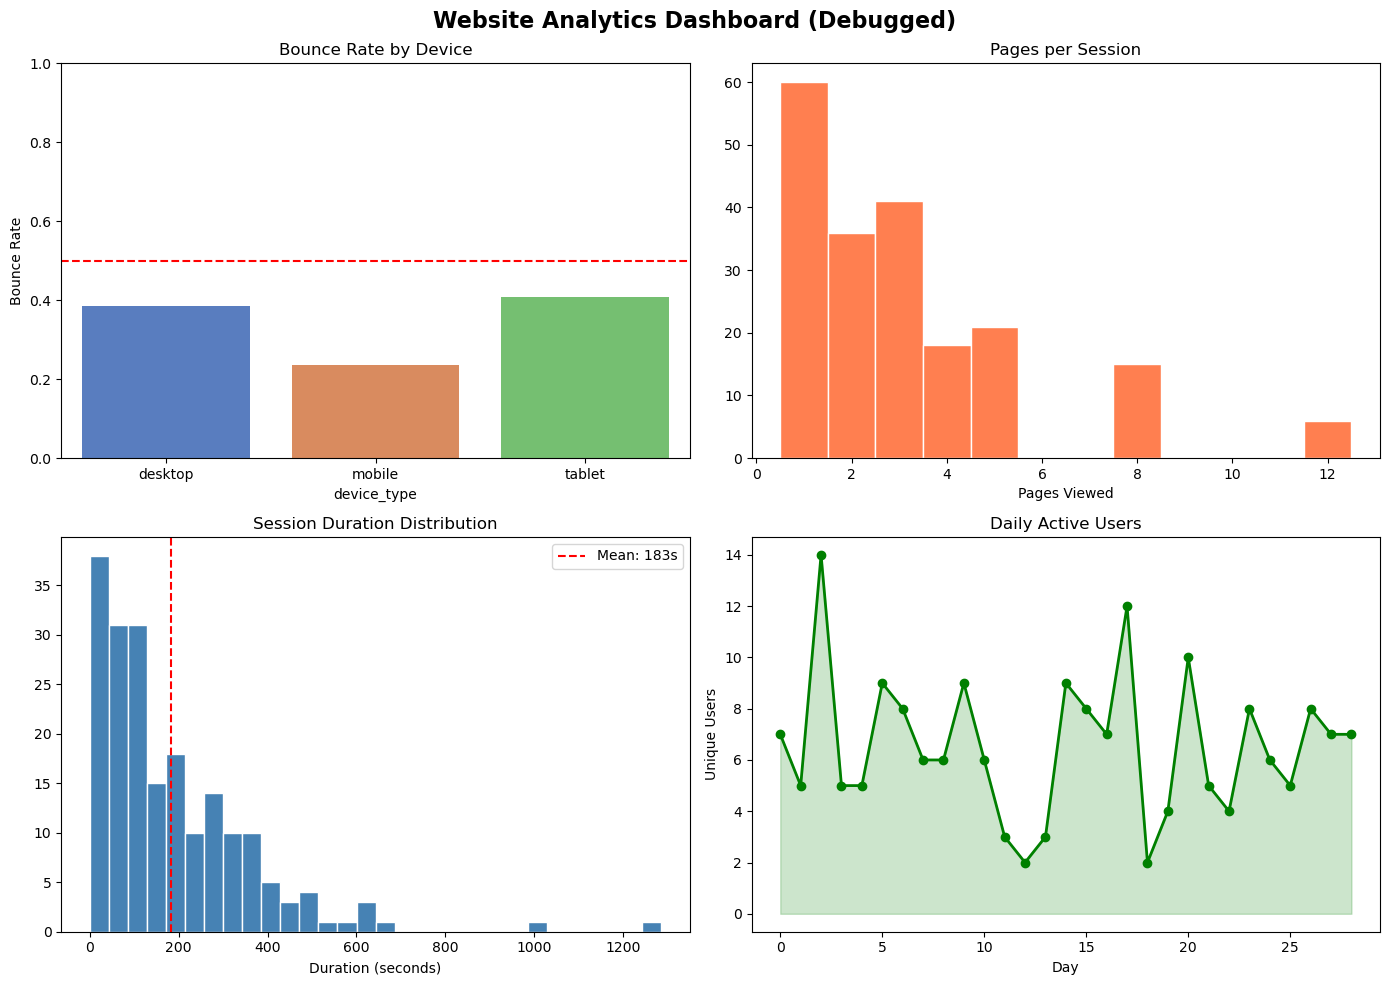

Dashboard saved.


In [6]:
# ── 4-Panel Dashboard ─────────────────────────────────────────────────────────
clean_df = logs_df[logs_df['duration'].between(0, 86400)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Website Analytics Dashboard (Debugged)', fontsize=16, fontweight='bold')

# Panel 1: Bounce rate by device
device_bounce = (clean_df.groupby(['device_type', 'session_id'])['page_views']
                 .sum().reset_index()
                 .assign(bounced=lambda d: d['page_views'] == 1)
                 .groupby('device_type')['bounced'].mean())
sns.barplot(x=device_bounce.index, y=device_bounce.values, palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('Bounce Rate by Device')
axes[0, 0].set_ylabel('Bounce Rate')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].axhline(0.5, color='red', linestyle='--')

# Panel 2: Session duration histogram
session_durations = clean_df.groupby('session_id')['duration'].sum()
axes[1, 0].hist(session_durations, bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Session Duration Distribution')
axes[1, 0].set_xlabel('Duration (seconds)')
axes[1, 0].axvline(session_durations.mean(), color='red', linestyle='--',
                    label=f'Mean: {session_durations.mean():.0f}s')
axes[1, 0].legend()

# Panel 3: Pages per session
pages_per = clean_df.groupby('session_id')['page_views'].sum()
axes[0, 1].hist(pages_per, bins=range(1, pages_per.max()+2),
                color='coral', edgecolor='white', align='left')
axes[0, 1].set_title('Pages per Session')
axes[0, 1].set_xlabel('Pages Viewed')

# Panel 4: Daily active users
dau = daily_active.reset_index()
dau.columns = ['date', 'users']
axes[1, 1].plot(range(len(dau)), dau['users'], marker='o', color='green', linewidth=2)
axes[1, 1].fill_between(range(len(dau)), dau['users'], alpha=0.2, color='green')
axes[1, 1].set_title('Daily Active Users')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Unique Users')

plt.tight_layout()
plt.savefig('scenario2_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")


## Follow-up Prompts

```
Follow-up 1:
"The bounce_rate is still above 1 in some test cases. Please confirm the lambda 
uses .all() not .any() and test with a single-row session."

Follow-up 2:
"Add a validation step that prints how many rows were removed and why, so the 
analyst can audit data quality."
```


## Discussion Answers

**1. How did different prompts approach error identification?**  
A vague prompt ("fix the engagement function") returned a refactored version but missed
the core lambda bug. Including the broken code and describing the symptoms directed the
AI to all three bugs precisely.

**2. What validation methods were suggested?**  
`dropna()` for nulls, boolean mask for negatives, and an upper-bound cap (`<= 86400`).
A more detailed prompt also added a printed audit log showing rows dropped.

**3. How was time handling improved?**  
The original `.sum()` per session was correct for total duration but the result stayed
as a Series. The fix was chaining `.mean()` to collapse it to a scalar. For
timestamp-based duration the AI showed `max(timestamp) - min(timestamp)` per group
using `.agg()`.
